# 7o Lab de PSD (notebook para preencher com os resultados)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Número do Grupo : 5

In [ ]:
#
# Primeiro vamos importar as bibliotecas necessárias
#
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# **1.0 - Definição do filtro de Gabor 2D (domínio espacial)**

O filtro de Gabor é um filtro do tipo passa-banda que possui alguns parâmetros que permitem que ele possa ser ajustado para realçar informações com diferentes escalas e orientações em uma imagem. A sua forma geral é dada pela equação abaixo.

$$\begin{aligned}
G(x,y; \lambda, \theta, \psi, \sigma, \gamma) = \exp \left( -\frac{(x'^2 + \gamma^2 y'^2}{2\sigma^2} \right) \cos\left( 2\pi \frac{x'}{\lambda} + \psi \right)
\end{aligned}$$

$$\begin{aligned}
x'&= (x-N/2)\cos\theta + (y-M/2)\sin\theta\\
y'&=-(x-N/2)\sin\theta + (y-M/2)\cos\theta\\
\end{aligned}$$

$\lambda$ = comprimento de onda do fator senoidal

$\theta$ = ângulo de orientação do filtro

$\gamma$ = controla a razão de aspecto do filtro

$\psi$ = fase da função senoidal

## **1.1 - Implementação do filtro de Gabor 2D**

Na implementação do filtro de Gabor 2D, utilizar uma máscara de tamanho $M \times N$, em que M=64 e N=64. Após a implementação do filtro, verifique se o filtro se encontra na forma normalizada, ou seja, que o máximo valor de coeficiente é igual a 1.0

In [ ]:
#
# Implementar a função Gabor 2D
#

def gabor(lamda, theta, psi, sigma, gamma, M, N):
    x = np.linspace(-N//2, N//2, N)
    y = np.linspace(-M//2, M//2, M)
    X, Y = np.meshgrid(x, y)

    d_x = X * np.cos(theta) + Y * np.sin(theta)
    d_y = -X * np.sin(theta) + Y * np.cos(theta)

    gaussiana = np.exp(-(d_x ** 2 + (gamma ** 2) * (d_y ** 2)) / (2 * sigma ** 2))
    cosseno = np.cos(2 * np.pi * (d_x / lamda) + psi)
    gab_filter =  gaussiana * cosseno

    return gab_filter

In [ ]:
# Verificando se o filtro se encontra na forma normalizada (máximo valor de coeficiente igual a 1)
gab = gabor(2*np.pi, np.pi / 2, 0, 1000, 1, 64, 64)

print("Coeficientes indo de 0 a 1 => Correto!")
print(gab)

Coeficientes indo de 0 a 1 => Correto!
[[0.83336955 0.83339621 0.83342202 ... 0.83342202 0.83339621 0.83336955]
 [0.90731359 0.90734262 0.90737071 ... 0.90737071 0.90734262 0.90731359]
 [0.12269494 0.12269887 0.12270266 ... 0.12270266 0.12269887 0.12269494]
 ...
 [0.12269494 0.12269887 0.12270266 ... 0.12270266 0.12269887 0.12269494]
 [0.90731359 0.90734262 0.90737071 ... 0.90737071 0.90734262 0.90731359]
 [0.83336955 0.83339621 0.83342202 ... 0.83342202 0.83339621 0.83336955]]


## 1.2 - Plotar, como imagem, os filtros de Gabor (par e ímpar) a partir do filtro implementado acima

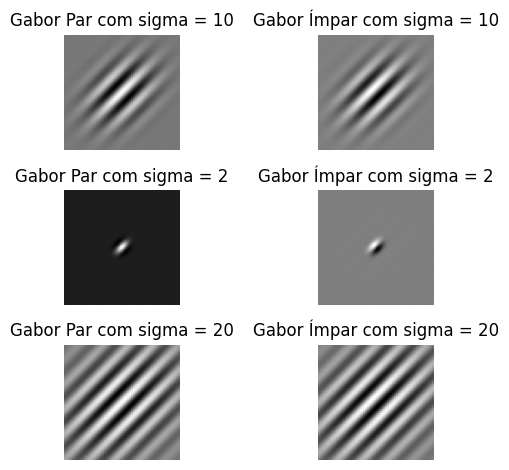

In [ ]:
# Plotar o filtro gerado usando a função matplotlib.pyplot.imshow
#
# -> Insira o seu código abaixo
#
lamda = 10
theta = 45 * (np.pi/180)
psi = 0
sigma = 10
gamma = 0.7
N = M = 64

plt.subplot(3,2,1)
gab = gabor(lamda, theta, psi, sigma, gamma, M, N)
plt.title("Gabor Par com sigma = 10")
plt.imshow(gab, cmap="gray")
plt.axis("off")

psi = 90 * (np.pi/180)

plt.subplot(3,2,2)
gab2 = gabor(lamda, theta, psi, sigma, gamma, M, N)
plt.title("Gabor Ímpar com sigma = 10")
plt.imshow(gab2, cmap="gray")
plt.axis("off")

sigma = 2
psi = 0

plt.subplot(3,2,3)
gab = gabor(lamda, theta, psi, sigma, gamma, M, N)
plt.title("Gabor Par com sigma = 2")
plt.imshow(gab, cmap="gray")
plt.axis("off")

psi = 90 * (np.pi/180)

plt.subplot(3,2,4)
gab2 = gabor(lamda, theta, psi, sigma, gamma, M, N)
plt.title("Gabor Ímpar com sigma = 2")
plt.imshow(gab2, cmap="gray")
plt.axis("off")

sigma = 20
psi = 0

plt.subplot(3,2,5)
gab = gabor(lamda, theta, psi, sigma, gamma, M, N)
plt.title("Gabor Par com sigma = 20")
plt.imshow(gab, cmap="gray")
plt.axis("off")

psi = 90 * (np.pi/180)

plt.subplot(3,2,6)
gab2 = gabor(lamda, theta, psi, sigma, gamma, M, N)
plt.title("Gabor Ímpar com sigma = 20")
plt.imshow(gab2, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

## 1.3 - Testes com diferentes filtros

Usando a imagem fornecida, faça a convolução da imagem com o filtro para os seguintes conjuntos de parâmetros:

a) Fixe $\gamma = \sigma = 1.0$, $\lambda = 0.2$ e $\psi=0$. Então, varie $\theta = 0^{°}, 45^{°}$ e $90^{°}$

b) Fixe $\gamma = 1.5$, $\sigma = 2.0$, $\lambda = 0.2$ e $\psi=0$. Então, varie $\theta = 0^{°}, 45^{°}$ e $90^{°}$

c) Para os dois conjuntos de parâmetros acima, modifique apenas o valor de $\psi$ para $\psi = \frac{\pi}{2}$ - Rode os experimentos novamente.

Para cada um dos itens acima, plote os filtros gerados e faça a convolução de cada um deles com a imagem fornecida para essa prática.
OBS: Observe que os ângulos precisam ser transformados de graus para radianos S(rad = graus * (pi/180.0))


## 1.3 - Filtros de Gabor usando OpenCV

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#
# Parâmetros do filro
#
ksize = 40
sigma = 2
theta = 0 #1*np.pi / 2
labda = 1*np.pi / 4
gamma = 1.0
phi = np.pi/2

#
# Usar a função getGaborKernel do OpenCV para criar um filtro Gabor com os parâmetros especificados acima
#

# -> INSERIR CÓDIGO AQUI
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)

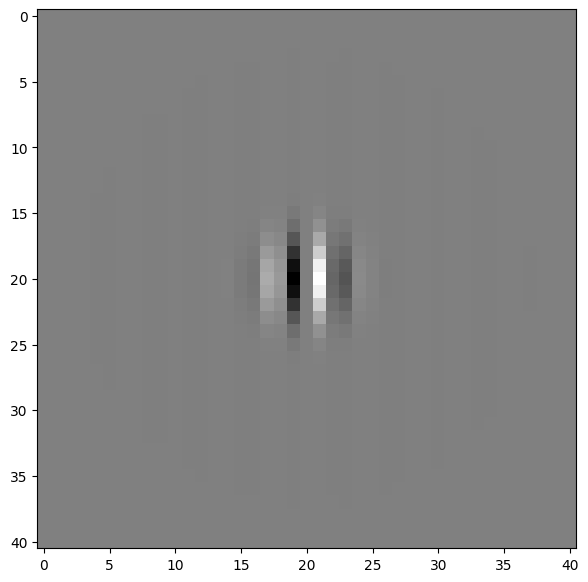

In [ ]:
#
# Plotar o filtro gerado usando a função matplotlib.pyplot.imshow
#

# -> INSERIR CÓDIGO AQUI
# Leitura de imagem
plt.figure(figsize=[7,7])
plt.imshow(filtro_gabor, cmap='gray')
plt.show()

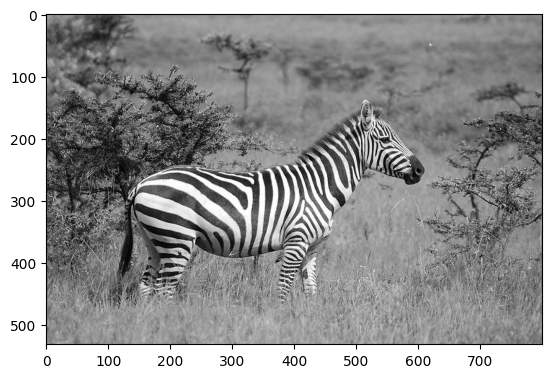

In [ ]:
imageRGB = cv2.imread('Zebra.jpg')
imageGRAY = cv2.cvtColor(imageRGB, cv2.COLOR_BGR2GRAY)
plt.imshow(imageGRAY, cmap="gray")

Item a)


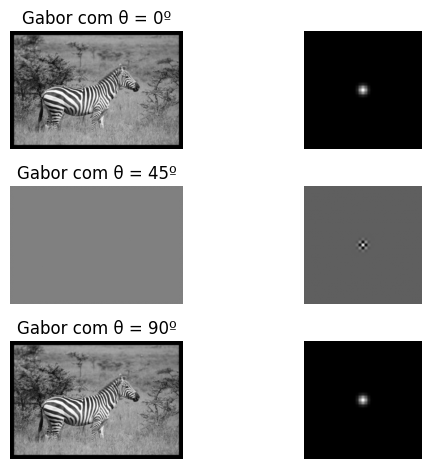

In [ ]:
# Usando a imagem fornecida, faça a convolução da imagem com o filtro para os seguintes conjuntos de parâmetros:

# a) Fixe  γ=σ=1.0 ,  λ=0.2  e  ψ=0 . Então, varie  θ=0∘,45∘  e  90∘

# b) Fixe  γ=1.5 ,  σ=2.0 ,  λ=0.2  e  ψ=0 . Então, varie  θ=0∘,45∘  e  90∘

# c) Para os dois conjuntos de parâmetros acima, modifique apenas o valor de  ψ  para  ψ=π2  - Rode os experimentos novamente.

# Para cada um dos itens acima, plote os filtros gerados e faça a convolução de cada um deles com a imagem fornecida para essa prática. OBS: Observe que os ângulos precisam ser transformados de graus para radianos S(rad = graus * (pi/180.0))
# Item a)
print("Item a)")
ksize = 40
sigma = 1
theta = 0
labda = 0.2
gamma = 1
phi = 0

plt.subplot(3,2,1)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 0º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,2)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 4

plt.subplot(3,2,3)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 45º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,4)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 2

plt.subplot(3,2,5)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 90º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,6)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

Item c) com o conjunto a)


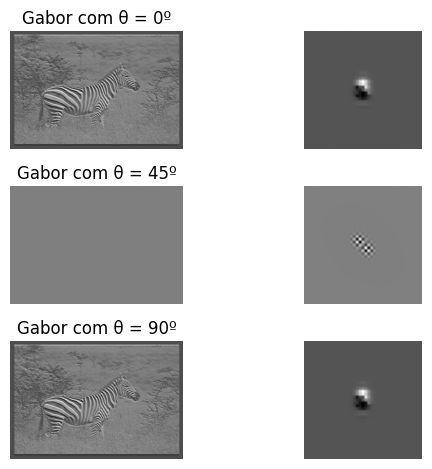

In [ ]:
print("Item c) com o conjunto a)")

phi = np.pi / 2

plt.subplot(3,2,1)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 0º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,2)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 4

plt.subplot(3,2,3)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 45º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,4)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 2

plt.subplot(3,2,5)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 90º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,6)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

Item b)


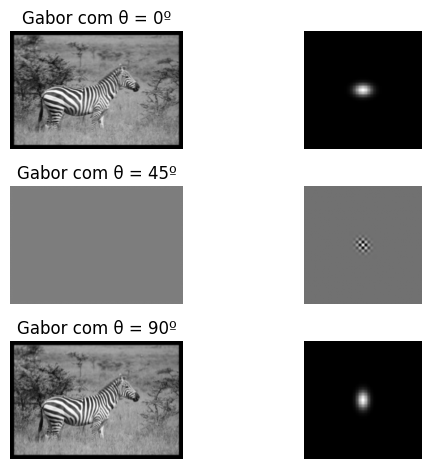

In [ ]:
print("Item b)")

ksize = 40
sigma = 2
theta = 0
labda = 0.2
gamma = 1.5
phi = 0

plt.subplot(3,2,1)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 0º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,2)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 4

plt.subplot(3,2,3)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 45º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,4)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 2

plt.subplot(3,2,5)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 90º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,6)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

Item c) com o conjunto b)


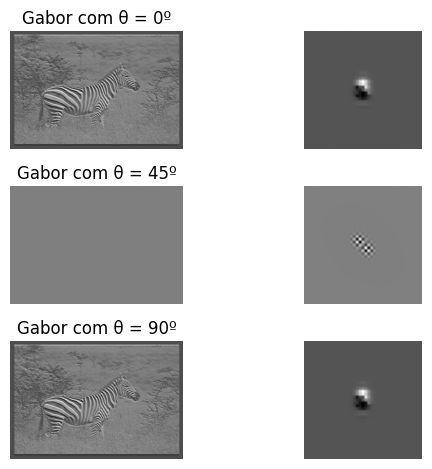

In [ ]:
print("Item c) com o conjunto b)")

phi = np.pi / 2

plt.subplot(3,2,1)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 0º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,2)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 4

plt.subplot(3,2,3)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 45º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,4)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

theta = np.pi / 2

plt.subplot(3,2,5)
filtro_gabor = cv2.getGaborKernel((ksize, ksize), sigma, theta, labda, gamma, phi)
img_conv = signal.convolve2d(imageGRAY, filtro_gabor)
plt.title("Gabor com θ = 90º")
plt.imshow(img_conv, cmap="gray")
plt.axis("off")

plt.subplot(3,2,6)
plt.imshow(filtro_gabor, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

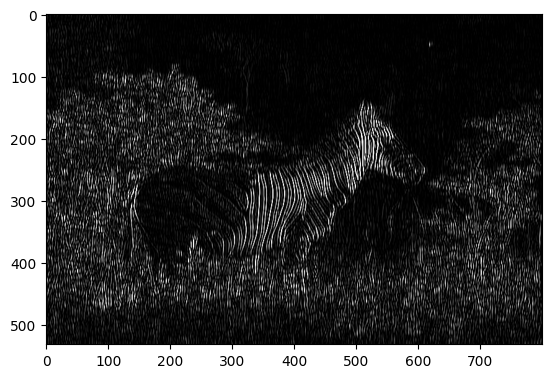

In [ ]:
#
# Utilizando a função filter2D do OpenCV, faça a convolução da imagem com o filtro Gabor
#
# OBS: modifique os parâmetros e verifique o que acontece com o resultado da filtragem
#

# -> INSERIR CÓDIGO AQUI
from scipy import signal

img_conv = cv2.filter2D(src=imageGRAY, ddepth=-1, kernel=filtro_gabor)
plt.imshow(img_conv, cmap="gray")

# Talvez apagar